<a href="https://colab.research.google.com/github/puhspi04/myproject/blob/main/yolo_p.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [5]:
import zipfile
import os

zip_path = "/content/archive.zip"   # change name
extract_path = "/content/archive"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted!")

✅ Dataset extracted!


In [6]:
!pip install ultralytics

In [12]:
BASE_DIR = '/content/archive/Main Dataset'

CLASSES = [folder for folder in os.listdir(BASE_DIR)
           if os.path.isdir(os.path.join(BASE_DIR, folder))]

print("Detected classes:", CLASSES)

Detected classes: ['MILK_CARTON', 'BOTTLE', 'UTENSIL', 'CAN', 'JUICE_BOX', 'STYROFOAM']


In [8]:
import xml.etree.ElementTree as ET

XML_DIR = '/content/archive/Main Dataset/BOTTLE'   # adjust if needed
LABELS_DIR = '/content/archive/labels'

os.makedirs(LABELS_DIR, exist_ok=True)

CLASSES = ['bottle']   # update if multiple classes

def convert_xml_to_yolo(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    size = root.find('size')
    w = int(size.find('width').text)
    h = int(size.find('height').text)

    yolo_lines = []

    for obj in root.findall('object'):
        cls = obj.find('name').text
        if cls not in CLASSES:
            continue

        cls_id = CLASSES.index(cls)

        xmlbox = obj.find('bndbox')
        xmin = int(xmlbox.find('xmin').text)
        xmax = int(xmlbox.find('xmax').text)
        ymin = int(xmlbox.find('ymin').text)
        ymax = int(xmlbox.find('ymax').text)

        # Convert
        x_center = ((xmin + xmax) / 2) / w
        y_center = ((ymin + ymax) / 2) / h
        width = (xmax - xmin) / w
        height = (ymax - ymin) / h

        yolo_lines.append(f"{cls_id} {x_center} {y_center} {width} {height}")

    return yolo_lines


# Run conversion
for file in os.listdir(XML_DIR):
    if file.endswith('.xml'):
        xml_path = os.path.join(XML_DIR, file)
        yolo_data = convert_xml_to_yolo(xml_path)

        txt_filename = file.replace('.xml', '.txt')
        txt_path = os.path.join(LABELS_DIR, txt_filename)

        with open(txt_path, 'w') as f:
            f.write('\n'.join(yolo_data))

print("✅ XML → YOLO conversion done!")

✅ XML → YOLO conversion done!


In [9]:
import shutil
import random

os.makedirs(f'{OUTPUT_DIR}/images/train', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/images/val', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/labels/train', exist_ok=True)
os.makedirs(f'{OUTPUT_DIR}/labels/val', exist_ok=True)

In [13]:
all_images = []

for class_name in CLASSES:
    class_path = os.path.join(BASE_DIR, class_name)

    for file in os.listdir(class_path):
        if file.endswith(('.png', '.jpg', '.jpeg')):
            all_images.append((class_name, file))

random.shuffle(all_images)

split = int(0.8 * len(all_images))
train_data = all_images[:split]
val_data = all_images[split:]

print(f"✅ Train: {len(train_data)} | Val: {len(val_data)}")

✅ Train: 1236 | Val: 310


In [14]:
def move_data(data, split_type):
    for class_name, file in data:
        img_src = os.path.join(BASE_DIR, class_name, file)

        base_name = file.rsplit('.', 1)[0]
        lbl_src = os.path.join(LABELS_DIR, base_name + '.txt')

        if os.path.exists(lbl_src):
            shutil.copy(img_src, f'{OUTPUT_DIR}/images/{split_type}/{file}')
            shutil.copy(lbl_src, f'{OUTPUT_DIR}/labels/{split_type}/{base_name}.txt')

move_data(train_data, 'train')
move_data(val_data, 'val')

print("✅ Dataset ready!")

✅ Dataset ready!


In [15]:
YOLO_YAML = '/content/archive.yaml'

names_yaml = '\n'.join([f'  {i}: {name.lower()}' for i, name in enumerate(CLASSES)])

yaml_content = f"""
path: {OUTPUT_DIR}
train: images/train
val: images/val

names:
{names_yaml}
"""

with open(YOLO_YAML, 'w') as f:
    f.write(yaml_content)

print("✅ archive.yaml created!")

✅ archive.yaml created!


In [16]:
import torch
from ultralytics import YOLO

CKPT_DIR = '/content/checkpoints'
YOLO_EPOCHS = 50

os.makedirs(f'{CKPT_DIR}/yolov8', exist_ok=True)

def train_yolov8(epochs=YOLO_EPOCHS):
    model = YOLO('yolov8n.pt')  # faster (use x later)

    model.train(
        data=YOLO_YAML,
        epochs=epochs,
        batch=16,
        imgsz=640,
        project=f'{CKPT_DIR}/yolov8',
        name='run',
        exist_ok=True
    )

    print("✅ Training complete!")
    return model

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [17]:
yolo_model = train_yolov8()

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/archive.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50       2.4G          0      106.9          0          0        640: 100% ━━━━━━━━━━━━ 21/21 5.8it/s 3.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 4.0it/s 0.5s
                   all         64          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50       2.4G          0       98.2          0          0        640: 100% ━━━━━━━━━━━━ 21/21 6.0it/s 3.5s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.9it/s 0.7s
                   all         64          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/50       2.4G          0      7.392          0          0        640: 100% ━━━━━━━━━━━━ 21/21 5.6it/s 3.8s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 6.0it/s 0.3s
                   all         64          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:839: RuntimeWarning: Mean of empty slice.
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



50 epochs completed in 0.076 hours.
Optimizer stripped from /content/checkpoints/yolov8/run/weights/last.pt, 6.2MB
Optimizer stripped from /content/checkpoints/yolov8/run/weights/best.pt, 6.2MB

Validating /content/checkpoints/yolov8/run/weights/best.pt...
Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 5.2it/s 0.4s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all         64          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 0.2ms preprocess, 2.8ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to /content/checkpoints/yolov8/run
✅ Training complete!


In [24]:
!find /content -name "*.png" | head

/content/archive/Main Dataset/MILK_CARTON/119-1196507_1-lowfat-select-milk-kemps-school-milk-carton.png
/content/archive/Main Dataset/MILK_CARTON/577e8b7f66c40bdf4bbc47374e04ed77.png
/content/archive/Main Dataset/MILK_CARTON/PF_SCHOOL-HPT_GROUP-2018.png
/content/archive/Main Dataset/MILK_CARTON/milk-e1395854958321.png
/content/archive/Main Dataset/MILK_CARTON/119-1196065_milk-carton-png-download-png-image-with-transpar.png
/content/archive/Main Dataset/MILK_CARTON/57-571166_look-for-our-new-school-milk-cartons-graphic.png
/content/archive/Main Dataset/MILK_CARTON/80-806214_milk-carton-kids-missing-children-in-us.png
/content/archive/Main Dataset/MILK_CARTON/milk-carton-clip-art-clipart-free-clipart.png
/content/archive/Main Dataset/MILK_CARTON/119-1196507_1-lowfat-select-milk-kemps-school-milk-carton (1).png
/content/archive/Main Dataset/BOTTLE/BOTTLE (46).png



image 1/1 /content/archive/Main Dataset/BOTTLE/BOTTLE (1).png: 640x640 (no detections), 9.3ms
Speed: 2.4ms preprocess, 9.3ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)


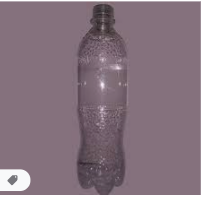

In [27]:
results = yolo_model.predict('/content/archive/Main Dataset/BOTTLE/BOTTLE (1).png', conf=0.5)
results[0].show()

In [28]:
metrics = yolo_model.val()
print(metrics)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 868.9±350.9 MB/s, size: 18.5 KB)
val: Scanning /content/archive/labels/val.cache... 64 images, 64 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 64/64 15.8Mit/s 0.0s
WARNING ⚠️ Labels are missing or empty in /content/archive/labels/val.cache, training may not work correctly. See https://docs.ultralytics.com/datasets for dataset formatting guidance.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 2.6it/s 1.5s


/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:657: RuntimeWarning: Mean of empty slice.
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:703: RuntimeWarning: Mean of empty slice.
  y = smooth(py.mean(0), 0.1)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:130: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/usr/local/lib/python3.12/dist-packages/ultraly

                   all         64          0          0          0          0          0
WARNING ⚠️ no labels found in detect set, cannot compute metrics without labels
Speed: 8.6ms preprocess, 6.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([], dtype=int64)
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ca73fad63c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,  

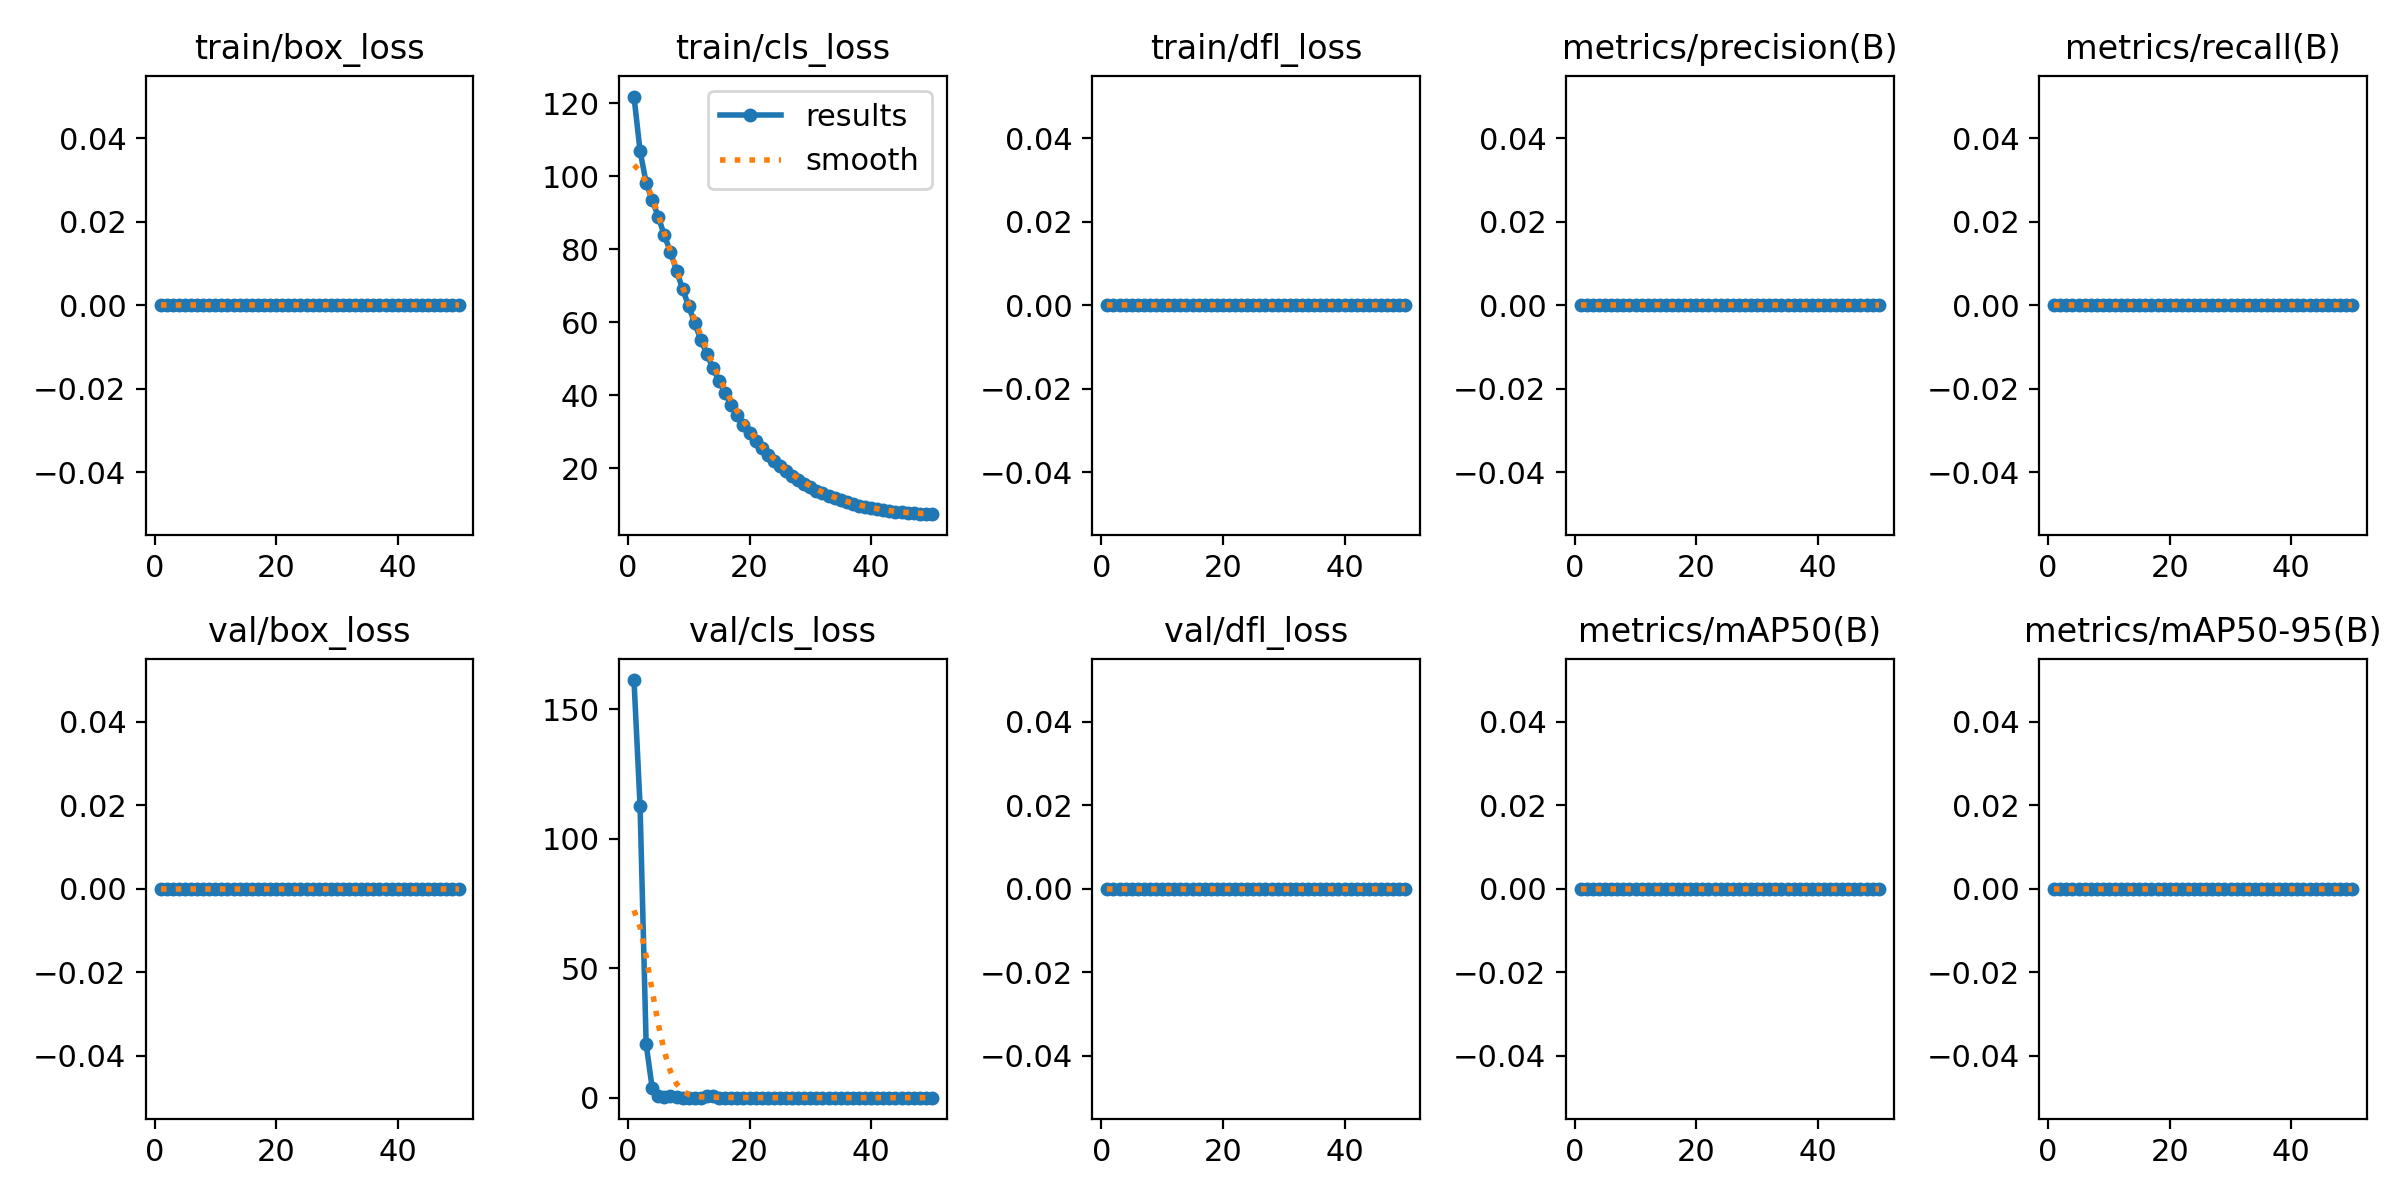

In [29]:
from IPython.display import Image, display

display(Image('/content/checkpoints/yolov8/run/results.png'))

In [38]:
!cat "/content/archive/Main Dataset/BOTTLE/BOTTLE (25).txt"

cat: '/content/archive/Main Dataset/BOTTLE/BOTTLE (25).txt': No such file or directory


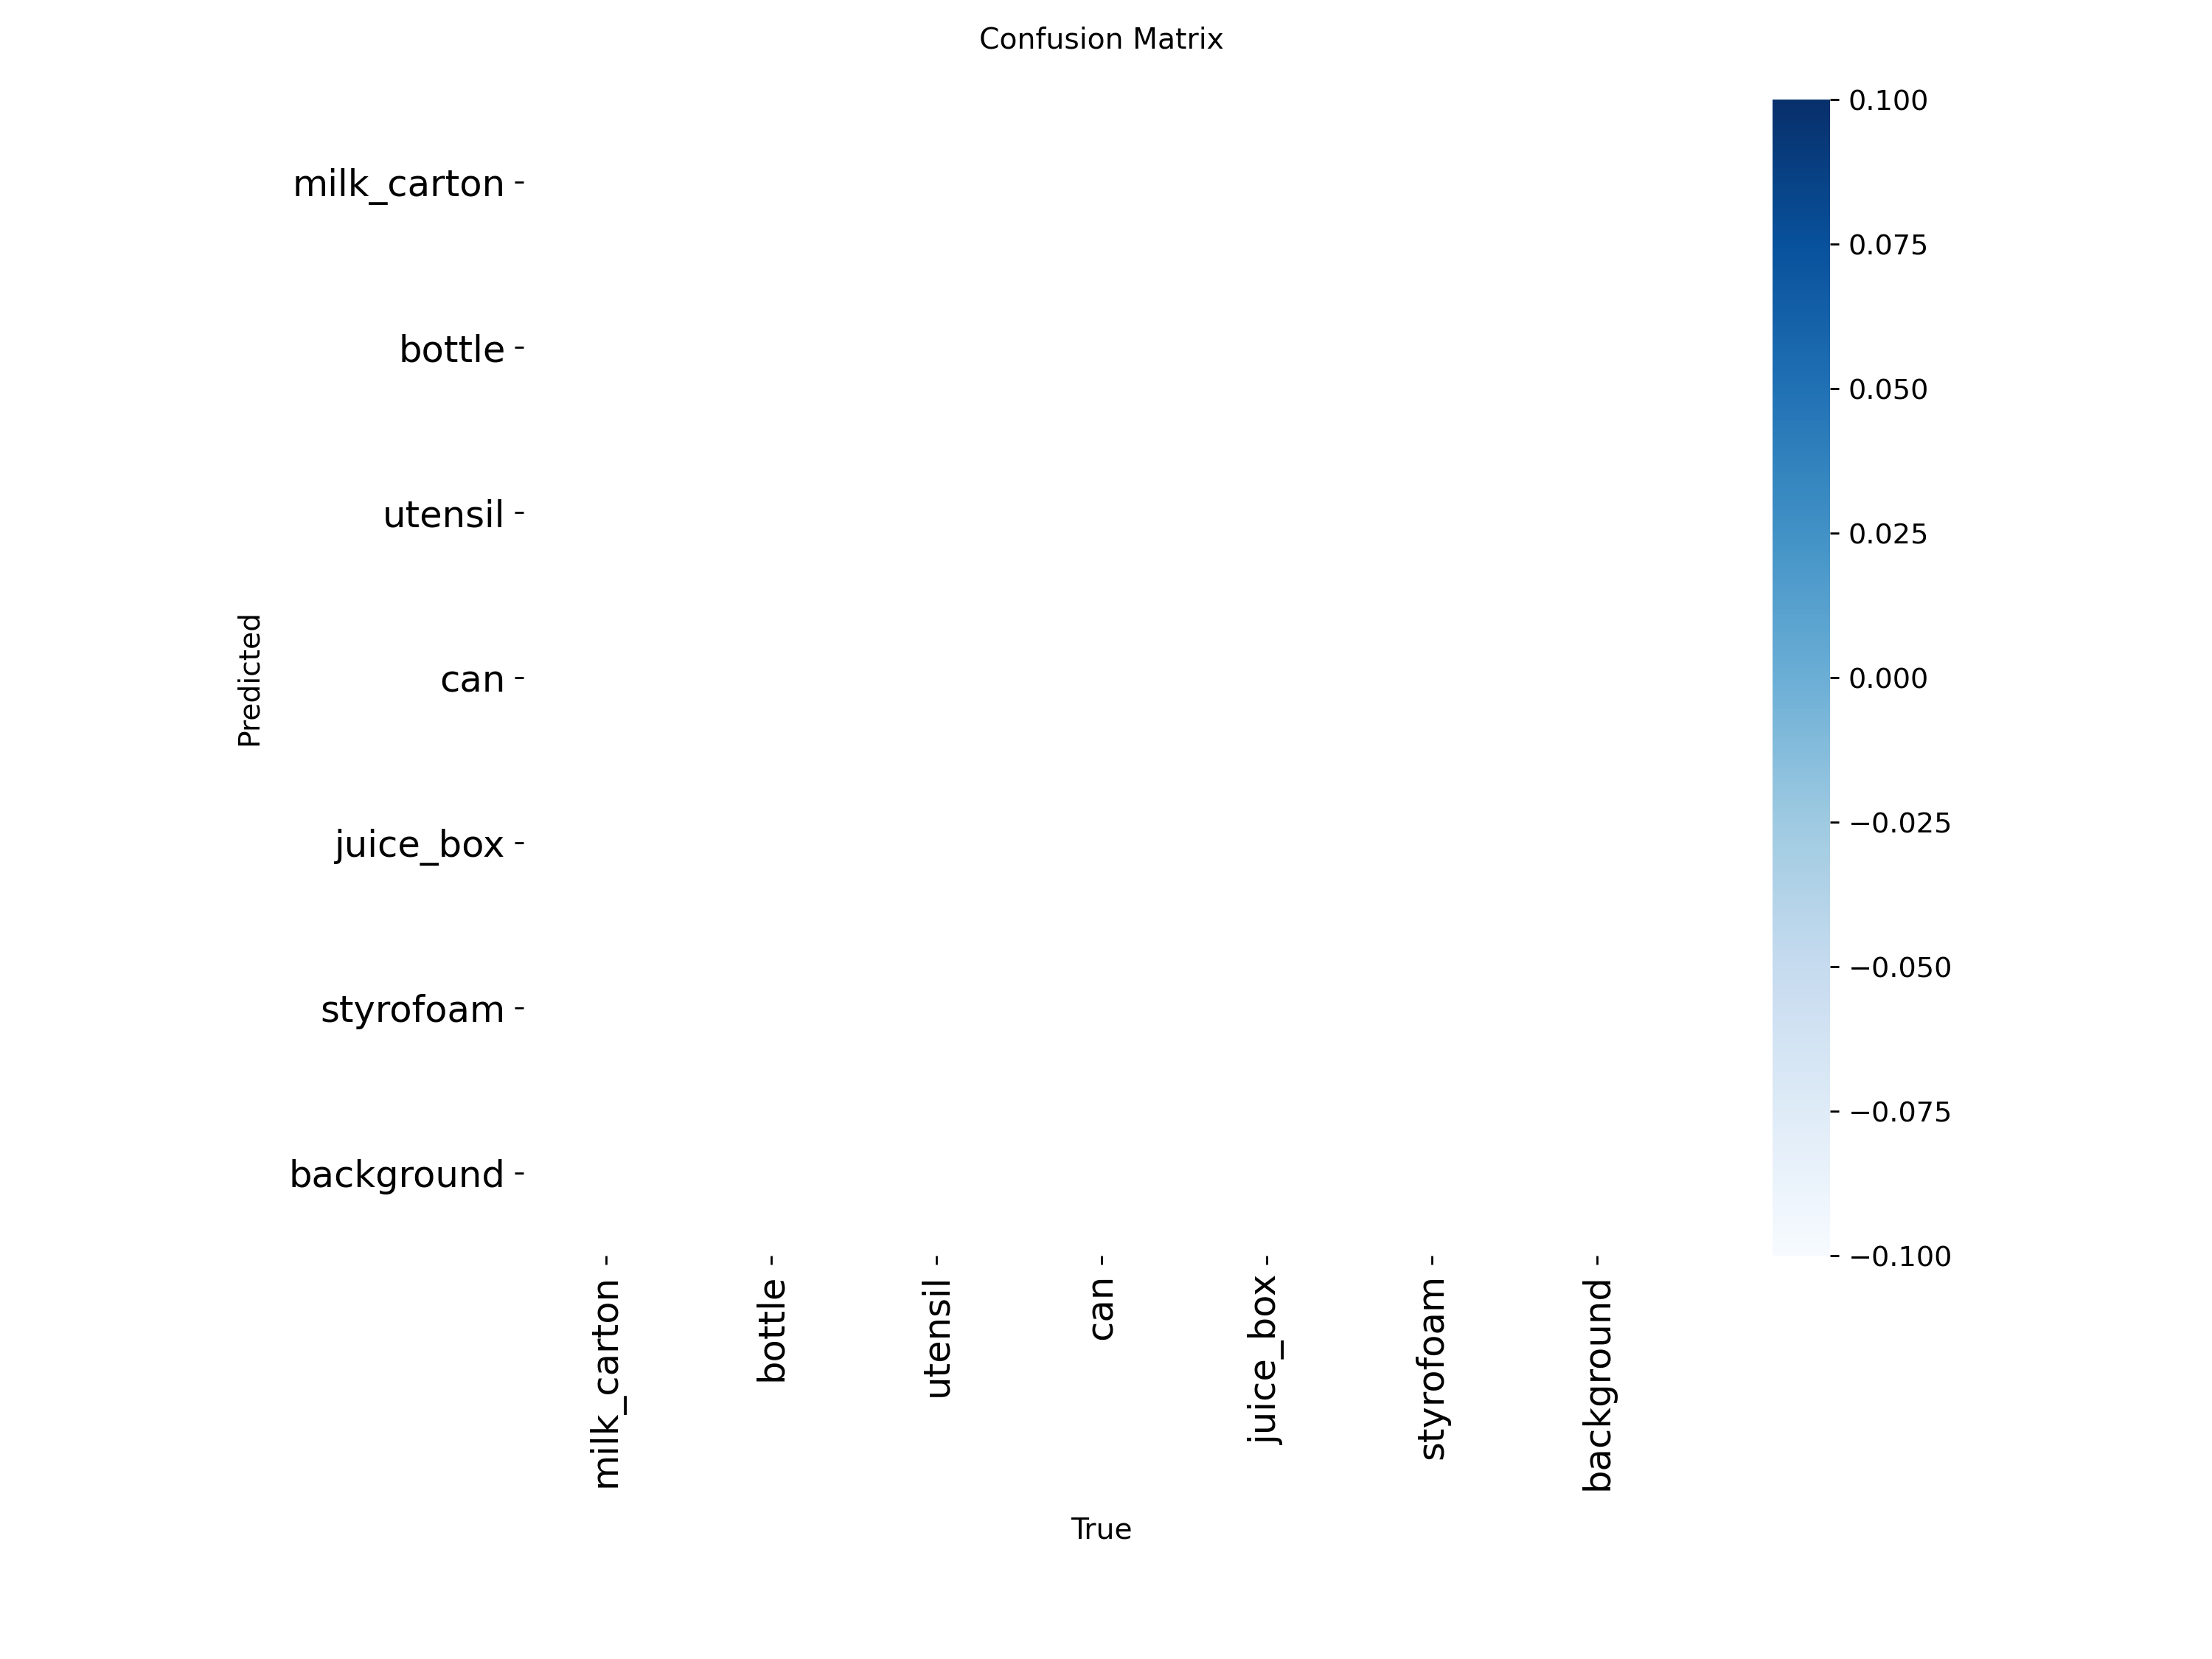

In [31]:
display(Image('/content/checkpoints/yolov8/run/confusion_matrix.png'))

In [32]:
display(Image('/content/checkpoints/yolov8/run/PR_curve.png'))

FileNotFoundError: No such file or directory: '/content/checkpoints/yolov8/run/PR_curve.png'

FileNotFoundError: No such file or directory: '/content/checkpoints/yolov8/run/PR_curve.png'

<IPython.core.display.Image object>